# MVP: *Machine Learning & Analytics*
**Autor:** Gustavo De Paola Barbieri

**Data:** 27/09/2025

**Matrícula:** 4052024001478

**Dataset:** Ex: [Sales Transactions Dataset Weekly](https://archive.ics.uci.edu/static/public/396/sales%2Btransactions%2Bdataset%2Bweekly.zip)





## 1. Escopo, objetivo e definição do problema

- Contexto do problema e objetivo: previsão de demanda semanal por produto, a partir do histórico de vendas. O objetivo é construir modelos de machine learning capazes de antecipar o volume de vendas futuras.

- Tipo de tarefa: regressão / séries temporais (forecasting).

- Área de aplicação: análise de dados tabulares temporais.

- Valor para o negócio/usuário: permite planejar melhor estoques, reposição e logística, reduzindo riscos de ruptura ou excesso de inventário, trazendo ganhos de eficiência operacional e suporte à tomada de decisão.


## 2. Reprodutibilidade e ambiente

In [37]:
from __future__ import annotations
import io, zipfile, requests, os, math, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import io, zipfile, requests


from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.ensemble import VotingRegressor

import joblib

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
pd.set_option('display.max_columns', 200)

print('Versões -> pandas', pd.__version__)

Versões -> pandas 2.2.2


### 2.2 Funções python
Nesta seção centralizamos todas as funções auxiliares criadas para reutilização no notebook.

In [38]:
# ==========================================================
# Funções auxiliares para métricas
# ==========================================================
def mape(y_true, y_pred, eps=1e-9):
    """Mean Absolute Percentage Error (MAPE)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + eps))) * 100

def wmape(y_true, y_pred, eps=1e-9):
    """Weighted Mean Absolute Percentage Error (WMAPE)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100

def evaluate_model(y_true, y_pred, label="Modelo"):
    """Retorna dicionário com métricas de avaliação."""
    return {
        "Modelo": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE%": mape(y_true, y_pred),
        "WMAPE%": wmape(y_true, y_pred),
    }

# ==========================================================
# Funções auxiliares para engenharia de atributos
# ==========================================================
def add_calendar_features(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    """Adiciona variáveis de calendário a partir da coluna de datas."""
    df = df.copy()
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    df['dayofweek'] = df[date_col].dt.dayofweek
    df['is_month_start'] = df[date_col].dt.is_month_start.astype(int)
    df['is_month_end'] = df[date_col].dt.is_month_end.astype(int)
    return df

def add_lags_rollings(
    df: pd.DataFrame,
    grp_cols: list[str],
    target: str,
    lags=(1, 2),
    rollings=((4, 1),)
) -> pd.DataFrame:
    """Cria lags e médias móveis (sem vazamento de dados)."""
    df = df.copy()
    parts = []
    for _, part in df.sort_values("date").groupby(grp_cols, group_keys=False):
        s = part[target]
        for L in lags:
            part[f"lag_{L}"] = s.shift(L)
        for w, minp in rollings:
            part[f"rollmean_{w}"] = s.shift(1).rolling(window=w, min_periods=minp).mean()
            part[f"rollstd_{w}"]  = s.shift(1).rolling(window=w, min_periods=minp).std()
        parts.append(part)
    return pd.concat(parts, axis=0)

# ==========================================================
# Funções de plot (com agregação por data)
# ==========================================================
def plot_predictions_agg(test_dates, y_true, y_pred, title="Real vs Previsto (agregado por data)"):
    """Plota série real vs prevista agregada por data, garantindo alinhamento."""
    s_true = pd.Series(y_true, index=test_dates).groupby(level=0).sum().sort_index()
    s_pred = pd.Series(y_pred, index=test_dates).groupby(level=0).sum().reindex(s_true.index)
    plt.figure(figsize=(10,4))
    plt.plot(s_true.index, s_true.values, label='Real (Agregado)')
    plt.plot(s_pred.index, s_pred.values, label='Previsto (Agregado)')
    plt.title(title); plt.xlabel('Data'); plt.ylabel('Vendas'); plt.legend(); plt.grid(True)
    plt.show()


## 3. Dados: carga, entendimento e qualidade
- Origem: UCI Machine Learning Repository — *Sales Transactions Dataset (Weekly)*.  
- Estrutura original: formato *wide* com colunas `W0..W51` (vendas semanais) por `product_code`.  
- Conversão: transformamos para *long* (`product_code`, `date`, `sales`) para modelagem temporal.  
- Qualidade: removemos nulos em `sales`, normalizamos nomes de colunas e ordenamos cronologicamente.  
- Ética/licença: dataset acadêmico público (UCI).  
- Vazamento: evitado ao criar lags/janelas com `shift(1)` e usar validação temporal.




In [39]:
# URL direta (zip) e leitura do UCI

UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/396/sales%2Btransactions%2Bdataset%2Bweekly.zip"

r = requests.get(UCI_ZIP_URL, timeout=60)
r.raise_for_status()
zf = zipfile.ZipFile(io.BytesIO(r.content))
with zf.open("Sales_Transactions_Dataset_Weekly.csv") as f:
    wide = pd.read_csv(f)

# Normalização de colunas
wide.columns = [c.strip().lower().replace(" ", "_") for c in wide.columns]

# Wide -> Long
week_cols = [c for c in wide.columns if c.startswith("w")]
long_df = (wide
           .melt(id_vars=["product_code"], value_vars=week_cols,
                 var_name="week", value_name="sales")
           .dropna())

# Eixo temporal semanal sintético
long_df["week_num"] = long_df["week"].str.extract(r"w(\d+)", expand=False).astype(int)
base_date = pd.Timestamp("2016-01-03")  # domingo
long_df["date"] = base_date + pd.to_timedelta(long_df["week_num"], unit="W")

# Tipagem e ordenação
long_df["sales"] = pd.to_numeric(long_df["sales"], errors="coerce")
long_df = long_df.dropna(subset=["sales"])
long_df["product_code"] = long_df["product_code"].astype(str)
long_df = long_df.sort_values(["date", "product_code"]).reset_index(drop=True)

print("Formato long:", long_df.shape,
      "| produtos:", long_df["product_code"].nunique(),
      "| semanas:", long_df["week_num"].nunique())
long_df.head()


Formato long: (42172, 5) | produtos: 811 | semanas: 52


,product_code,week,sales,week_num,date
0,P1,w0,11,0,2016-01-03
1,P10,w0,22,0,2016-01-03
2,P100,w0,13,0,2016-01-03
3,P101,w0,26,0,2016-01-03
4,P102,w0,34,0,2016-01-03


## 3.1 Análise exploratória resumida (EDA)

A análise exploratória buscou identificar padrões de comportamento das vendas e levantar hipóteses que orientem a modelagem. Três visualizações principais foram utilizadas:

- Tendência semanal: há queda acentuada em junho/julho e recuperação depois, sugerindo sazonalidade.

- Top 10 produtos: forte concentração em poucos itens (ex.: P409), típico de curva ABC; erros nesses produtos impactam muito no resultado, justificando uso de métricas ponderadas (WMAPE).

- Distribuição das vendas: enviesada à direita, com muitas vendas baixas e poucos picos; reforça a importância de métricas robustas (MAE/WMAPE) e cuidado com outliers.



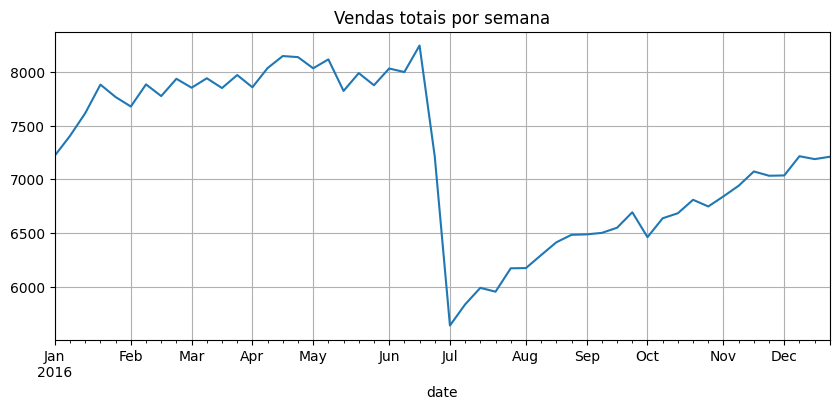

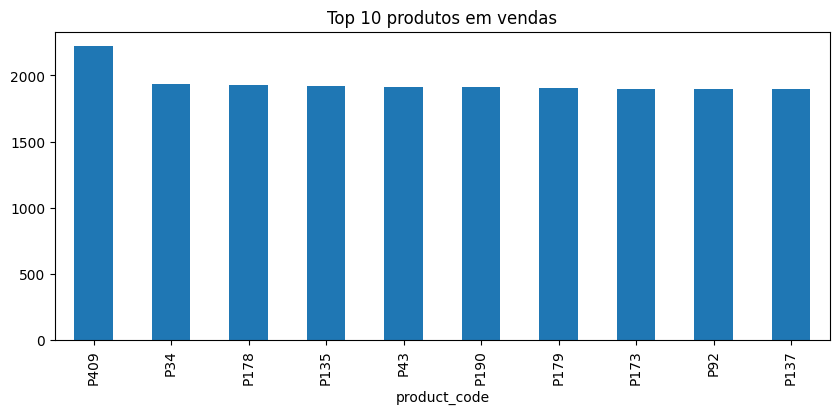

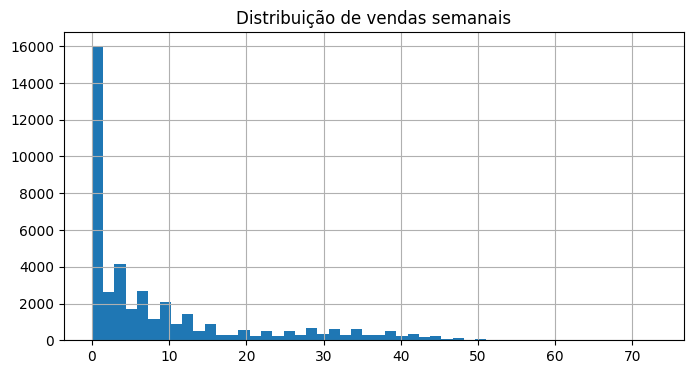

In [40]:
# Tendência agregada semanal
long_df.groupby('date')['sales'].sum().plot(figsize=(10,4), grid=True, title="Vendas totais por semana")
plt.show();

# Top 10 produtos por volume total
top_products = long_df.groupby('product_code')['sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(10,4), title="Top 10 produtos em vendas")
plt.show();

# Distribuição de vendas semanais
long_df['sales'].hist(bins=50, figsize=(8,4)); plt.title("Distribuição de vendas semanais")
plt.show();



## 4. Definição do target, variáveis e divisão dos dados
- Target: `sales` (venda semanal por produto).  
- Em séries temporais: não embaralhar; usar divisões temporais (ex.: `TimeSeriesSplit`).  
- Pipelines: todas as transformações são ajustadas no **treino** e aplicadas no **teste** para evitar vazamento.


In [41]:
# Engenharia de atributos (usa funções da Seção 2.2)
df_feat = add_calendar_features(long_df, date_col="date")
df_feat = add_lags_rollings(df_feat, grp_cols=["product_code"], target="sales",
                            lags=(1,2), rollings=((4,1),))
df_feat = df_feat.dropna(subset=["lag_1","lag_2"]).reset_index(drop=True)

print("Com features:", df_feat.shape)
df_feat.head()

# Split temporal (70/30)
TRAIN_FRAC = 0.7
all_dates = np.sort(df_feat['date'].unique())
cut_idx = int(len(all_dates) * TRAIN_FRAC)
TRAIN_END = pd.to_datetime(all_dates[cut_idx - 1])

train_df = df_feat[df_feat['date'] <= TRAIN_END].copy()
test_df  = df_feat[df_feat['date'] >  TRAIN_END].copy()

numeric_feats = ['year','month','day','dayofweek','is_month_start','is_month_end',
                 'lag_1','lag_2','rollmean_4','rollstd_4']
categorical_feats = ['product_code']

X_train = train_df[numeric_feats + categorical_feats].copy()
y_train = train_df['sales'].copy()
X_test  = test_df[numeric_feats + categorical_feats].copy()
y_test  = test_df['sales'].copy()

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Datas treino:', train_df['date'].min().date(), '→', train_df['date'].max().date(),
      '| Datas teste:', test_df['date'].min().date(), '→', test_df['date'].max().date())


Com features: (40550, 15)
Train: (28385, 11) | Test: (12165, 11)
Datas treino: 2016-01-17 → 2016-09-11 | Datas teste: 2016-09-18 → 2016-12-25


## 5. Tratamento de dados e Pipeline de pré-processamento
Pipeline com imputação, escala e codificação categórica para garantir reprodutibilidade e evitar vazamento.


In [42]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]), numeric_feats),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.02))]), categorical_feats),
    ],
    remainder='drop'
)

## 6. Baseline, modelos candidatos e validação com otimização de hiperparâmetros
Nesta seção reunimos:
- Baseline simples (Lag-1).
- Modelos candidatos (Linear, Ridge, Lasso, RandomForest, KNN, SVR).
- Validação temporal com `TimeSeriesSplit`.
- Otimização de hiperparâmetros via `RandomizedSearchCV`.
- Comparação de métricas entre baseline e melhores modelos.


In [43]:
# Baseline simples: usa lag_1 como previsão no teste
baseline_pred = test_df['lag_1'].values
baseline_metrics = evaluate_model(y_test, baseline_pred, label="Baseline (Lag-1)")
baseline_metrics


{'Modelo': 'Baseline (Lag-1)',
 'MAE': 2.688779284833539,
 'RMSE': 4.365833418552891,
 'R2': 0.8437985640703467,
 'MAPE%': np.float64(54.09413349412966),
 'WMAPE%': np.float64(31.725201501440026)}

### 6.1 Treino e avaliação (baseline vs candidatos)
Usamos métricas MAE, RMSE, R², MAPE e WMAPE para comparar desempenho.


In [44]:
N_SPLITS = 2
N_ITER   = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

candidates = {
    'LinearRegression': Pipeline([('prep', preprocess), ('est', LinearRegression())]),
    'Ridge':            Pipeline([('prep', preprocess), ('est', Ridge(random_state=SEED))]),
    'Lasso':            Pipeline([('prep', preprocess), ('est', Lasso(random_state=SEED, max_iter=5000))]),
    'RandomForest':     Pipeline([('prep', preprocess), ('est', RandomForestRegressor(random_state=SEED, n_jobs=-1))]),
    'KNN':              Pipeline([('prep', preprocess), ('est', KNeighborsRegressor())]),
    'SVR':              Pipeline([('prep', preprocess), ('est', SVR())]),
}

param_spaces = {
    'LinearRegression': {'est__fit_intercept': [True, False]},
    'Ridge':            {'est__alpha': [0.1, 1.0, 10.0, 50.0]},
    'Lasso':            {'est__alpha': [0.0005, 0.001, 0.01, 0.1]},
    'RandomForest':     {'est__n_estimators': [120, 200], 'est__max_depth': [None, 8]},
    'KNN':              {'est__n_neighbors': [3, 5, 7], 'est__weights': ['uniform', 'distance']},
    'SVR':              {'est__kernel': ['linear', 'rbf'], 'est__C': [0.5, 1.0, 5.0], 'est__epsilon': [0.01, 0.1]},
}

results, best_models = [], {}

for name, pipe in candidates.items():
    print(f"\nTreinando {name}...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[name],
        n_iter=N_ITER,
        scoring='neg_mean_absolute_error',
        cv=tscv,
        n_jobs=-1,
        refit=True,
        random_state=SEED,
        verbose=0
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    tr_time = time.time() - t0

    best = search.best_estimator_
    y_pred = best.predict(X_test)
    results.append({
        'model': name,
        'best_params': search.best_params_,
        'fit_time_s': round(tr_time, 2),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'MAPE%': mape(y_test, y_pred),
        'WMAPE%': wmape(y_test, y_pred),
    })
    best_models[name] = best

results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df



Treinando LinearRegression...

Treinando Ridge...

Treinando Lasso...

Treinando RandomForest...

Treinando KNN...

Treinando SVR...


,model,best_params,fit_time_s,MAE,RMSE,R2,MAPE%,WMAPE%
0,RandomForest,"{'est__n_estimators': 200, 'est__max_depth': 8}",41.90,2.215099,3.540181,0.897293,43.626894,26.136198
1,SVR,"{'est__kernel': 'linear', 'est__epsilon': 0.01...",163.93,2.237214,3.625303,0.892294,43.092118,26.397133
2,Lasso,{'est__alpha': 0.001},0.66,2.253759,3.626957,0.892196,43.556343,26.592348
3,Ridge,{'est__alpha': 1.0},0.71,2.254112,3.627393,0.892170,43.561688,26.596513
4,LinearRegression,{'est__fit_intercept': True},4.03,2.254131,3.627463,0.892166,43.560398,26.596735
5,KNN,"{'est__weights': 'distance', 'est__n_neighbors...",3.28,2.359572,3.726715,0.886184,46.578308,27.840852


### 6.2 Ensemble — VotingRegressor
Combinamos os três melhores modelos individuais em um **VotingRegressor** para buscar ganho de generalização.


Top-3 modelos para ensemble: ['RandomForest', 'SVR', 'Lasso']
VotingRegressor — métricas no teste:
  MAE: 2.2029
  RMSE: 3.5414
  R2: 0.8972
  MAPE%: 43.0189
  WMAPE%: 25.9928


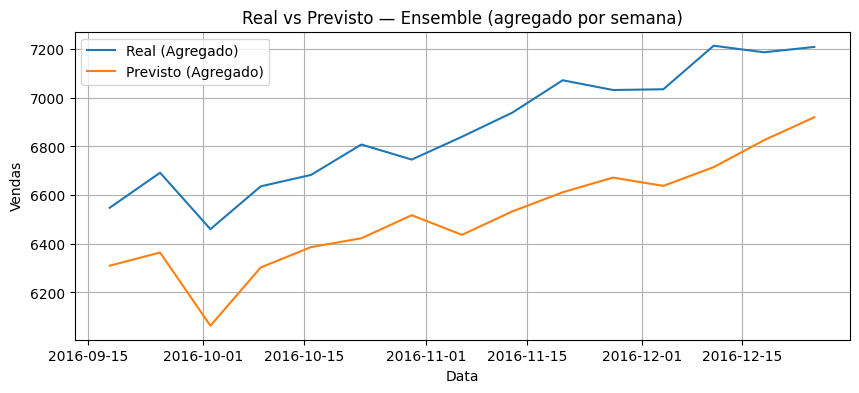

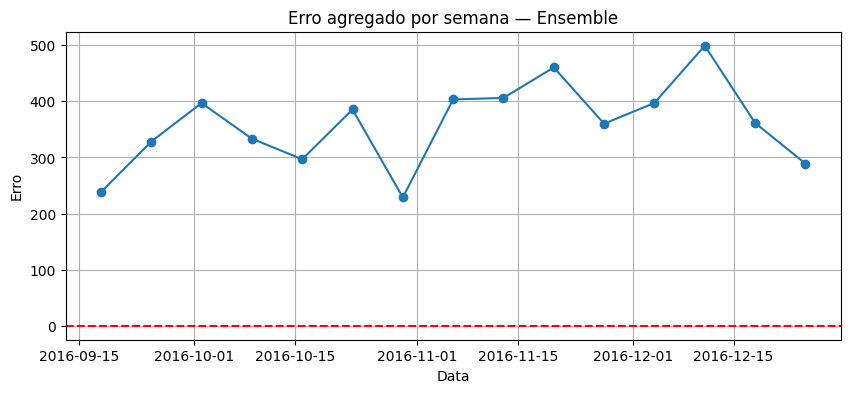

In [45]:

# Top-3 por MAE
top3 = results_df.sort_values('MAE').head(3)['model'].tolist()
estimators = [(m, best_models[m]) for m in top3 if m in best_models]
print("Top-3 modelos para ensemble:", top3)

if len(estimators) >= 2:
    voting = VotingRegressor(estimators=estimators)
    voting.fit(X_train, y_train)
    y_pred_vote = voting.predict(X_test)

    voting_metrics = evaluate_model(y_test, y_pred_vote, label="VotingRegressor")
    print("VotingRegressor — métricas no teste:")
    for k, v in voting_metrics.items():
        if k != "Modelo":
            print(f"  {k}: {v:.4f}")

    # Ensemble (VotingRegressor)

    # Garante alinhamento 1:1 entre datas, reais e previstos
    eval_vote = pd.DataFrame({
        'date': np.asarray(test_df['date']).ravel(),
        'y_true': np.asarray(y_test).ravel(),
        'y_pred': np.asarray(y_pred_vote).ravel()
    })
    # Remove possíveis NaNs e ordena
    eval_vote = eval_vote.dropna().sort_values('date').reset_index(drop=True)

    # Agrega por data (semanas)
    weekly_vote = (eval_vote
                   .groupby('date', as_index=False)
                   .agg(y_true_sum=('y_true','sum'),
                        y_pred_sum=('y_pred','sum')))

    # Plot Real vs Previsto (agregado)
    plt.figure(figsize=(10,4))
    plt.plot(weekly_vote['date'], weekly_vote['y_true_sum'], label='Real (Agregado)')
    plt.plot(weekly_vote['date'], weekly_vote['y_pred_sum'], label='Previsto (Agregado)')
    plt.title('Real vs Previsto — Ensemble (agregado por semana)')
    plt.xlabel('Data'); plt.ylabel('Vendas'); plt.legend(); plt.grid(True); plt.show()

    # Erro agregado do ensemble (real - previsto)
    weekly_vote['erro'] = weekly_vote['y_true_sum'] - weekly_vote['y_pred_sum']

    plt.figure(figsize=(10,4))
    plt.plot(weekly_vote['date'], weekly_vote['erro'], marker='o')
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Erro agregado por semana — Ensemble')
    plt.xlabel('Data'); plt.ylabel('Erro'); plt.grid(True); plt.show()
else:
    print("Não há estimadores suficientes para criar o VotingRegressor.")



## 7. Avaliação final, análise de erros e limitações
Comparamos **baseline (Lag-1)** versus **melhor modelo** e analisamos os *resíduos** para entender padrões de erro.


Melhor modelo: RandomForest 
Parâmetros: {'est__n_estimators': 200, 'est__max_depth': 8}
Comparativo — Melhor vs Baseline


,Baseline,Melhor
Modelo,Baseline (Lag-1),RandomForest
MAE,2.688779,2.215099
RMSE,4.365833,3.540181
R2,0.843799,0.897293
MAPE%,54.094133,43.626894
WMAPE%,31.725202,26.136198


Resumo por semana (Top-10 maiores erros absolutos):


,date,y_true_sum,y_pred_sum,erro,abs_erro,APE%
2,2016-10-02,6460,5779.578927,680.421073,680.421073,10.532834
12,2016-12-11,7214,6840.297405,373.702595,373.702595,5.180241
10,2016-11-27,7032,6691.522667,340.477333,340.477333,4.841828
9,2016-11-20,7072,6732.415988,339.584012,339.584012,4.801810
5,2016-10-23,6808,6504.766297,303.233703,303.233703,4.454079
11,2016-12-04,7035,6767.146194,267.853806,267.853806,3.807446
7,2016-11-06,6840,6596.319751,243.680249,243.680249,3.562577
13,2016-12-18,7187,6945.118982,241.881018,241.881018,3.365535
8,2016-11-13,6939,6709.965838,229.034162,229.034162,3.300680
1,2016-09-25,6692,6492.018786,199.981214,199.981214,2.988362


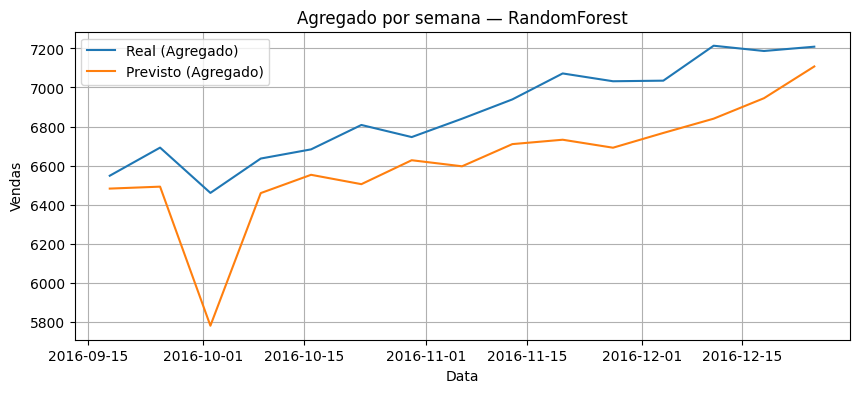

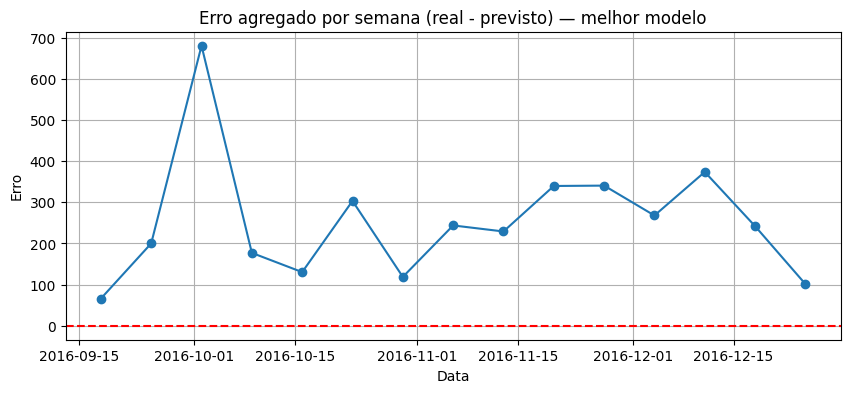

In [46]:
# ==========================================================
# 8. Avaliação final, análise de erros e limitações
# ==========================================================

# Melhor modelo e comparação com baseline
best_row = results_df.iloc[0]
best_name = best_row['model']
best_pipe = best_models[best_name]

print('Melhor modelo:', best_name, '\nParâmetros:', best_row['best_params'])

y_pred_test = best_pipe.predict(X_test)

print('Comparativo — Melhor vs Baseline')
display(pd.DataFrame([
    pd.Series(baseline_metrics).rename('Baseline'),
    pd.Series(evaluate_model(y_test, y_pred_test, label=best_name)).rename('Melhor')
]).T)


# ===========================
# CURVA AGREGADA REAL vs PREVISTO
# ===========================
eval_df = test_df[['date','product_code']].copy()
eval_df['y_true'] = y_test
eval_df['y_pred'] = y_pred_test

# Agregação por data
weekly_stats = (
    eval_df.groupby('date')
    .agg(
        y_true_sum=('y_true','sum'),
        y_pred_sum=('y_pred','sum')
    )
    .reset_index()
)

# Cálculo de erros
weekly_stats['erro'] = weekly_stats['y_true_sum'] - weekly_stats['y_pred_sum']
weekly_stats['abs_erro'] = weekly_stats['erro'].abs()
weekly_stats['APE%'] = (weekly_stats['abs_erro'] / weekly_stats['y_true_sum'].replace(0,1e-9)) * 100

print("Resumo por semana (Top-10 maiores erros absolutos):")
display(weekly_stats.sort_values('abs_erro', ascending=False).head(10))

# Gráfico real vs previsto
plt.figure(figsize=(10,4))
plt.plot(weekly_stats['date'], weekly_stats['y_true_sum'], label='Real (Agregado)')
plt.plot(weekly_stats['date'], weekly_stats['y_pred_sum'], label='Previsto (Agregado)')
plt.title(f'Agregado por semana — {best_name}')
plt.xlabel('Data'); plt.ylabel('Vendas'); plt.legend(); plt.grid(True); plt.show()

# Gráfico de erros agregados
plt.figure(figsize=(10,4))
plt.plot(weekly_stats['date'], weekly_stats['erro'], marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title('Erro agregado por semana (real - previsto) — melhor modelo')
plt.xlabel('Data'); plt.ylabel('Erro'); plt.grid(True); plt.show()




## 8. Engenharia de atributos (detalhe)
- Calendário: `year`, `month`, `day`, `dayofweek`, `is_month_start`, `is_month_end`.  
- Temporais: `lag_1`, `lag_2`, `rollmean_4`, `rollstd_4` — todas **defasadas** com `shift(1)` para evitar vazamento.  
- Categóricas: `product_code` com **OneHotEncoder** usando `min_frequency` para controlar cardinalidade e estabilidade.  



## 9. Boas práticas e rastreabilidade
- Baseline claro (Lag-1) e evolução para modelos mais fortes com **justificativas por métricas**.  
- Pipelines (`ColumnTransformer` + `Pipeline`) evitando vazamento e garantindo reprodutibilidade.  
- Decisões de projeto documentadas:** validação temporal (TSCV), espaços de busca compactos, features coerentes.  
- Seeds fixas em todas as etapas relevantes.
- Tempo de Treino: 3 minutos


## 10. Conclusões e próximos passos
O RandomForest apresentou a melhor performance frente ao baseline (lag-1), com ganhos em todas as métricas (ex.: MAE e RMSE menores; R² próximo a 0,90; WMAPE reduzido). O modelo captura adequadamente a tendência semanal agregada, embora suavize picos.

Limitações. Séries curtas e ausência de variáveis exógenas reais (promoções/feriados específicos) limitam a captura de choques.
Próximos passos. 1) testar GBDTs (XGBoost/LightGBM) e SARIMA para captura de possível sazonalidade; 2) incluir covariáveis (promoções, calendário real, preços); 3) avaliar importância de atributos (permutação/SHAP) para refino


## 11. Salvando artefatos (modelos e pipeline)
Salvamos o melhor modelo e a tabela de resultados para facilitar reuso sem re-treinar.


In [48]:
ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

best_name = results_df.iloc[0]['model']
best_pipe = best_models[best_name]

model_path = os.path.join(ARTIFACTS_DIR, f'model_{best_name.lower()}.joblib')
joblib.dump(best_pipe, model_path)

results_csv = os.path.join(ARTIFACTS_DIR, 'model_results_all_products.csv')
results_df.to_csv(results_csv, index=False)

print('Artefatos salvos:'); print('-', model_path); print('-', results_csv)

# Carregar modelo salvo
loaded_model = joblib.load(model_path)

# Fazer previsões com o modelo carregado
y_pred_loaded = loaded_model.predict(X_test)


# Carregar modelo salvo (sem re-treinar)
loaded_model = joblib.load("artifacts/model_randomforest.joblib")

# Usar o modelo carregado para prever
y_pred_loaded = loaded_model.predict(X_test)

# Conferir se funciona
print("Primeiras previsões:", y_pred_loaded[:5])



Artefatos salvos:
- artifacts/model_randomforest.joblib
- artifacts/model_results_all_products.csv
Primeiras previsões: [ 8.84934174  9.27420091 11.215334   11.81232012 10.85936984]


# Checklist — Projeto MVP Previsão de Demanda

## 1. Definição do Problema
- **Descrição:** prever vendas futuras de produtos com base no histórico.  
- **Hipóteses:** vendas têm padrão temporal e sazonal.  
- **Restrições:** dados públicos do UCI, sem informações sensíveis.  
- **Dataset:** registros de vendas por produto e data, com atributos básicos e variáveis criadas (lags, médias móveis e calendário).  

---

## 2. Preparação de Dados
- **Divisão:** treino e teste respeitando ordem temporal.  
- **Validação:** usamos TimeSeriesSplit.  
- **Transformações:** encoding, normalização, criação de lags e médias móveis.  
- **Seleção de atributos:** principais variáveis testadas com RandomForest.

---

## 3. Modelagem e Treinamento
- **Modelos:** baseline (lag-1), Linear, Lasso, Ridge, SVR, RandomForest.  
- **Tuning:** ajuste de hiperparâmetros simples com validação cruzada.  
- **Treinamento:** todos rodaram sem underfitting.  
- **Ensemble:** VotingRegressor com os 3 melhores modelos.  

---

## 4. Avaliação de Resultados
- **Métricas:** MAE, RMSE, R², MAPE, WMAPE.  
- **Comparação:** baseline teve maior erro; RandomForest obteve melhor desempenho; ensemble ficou próximo.  
- **Resultados:** coerentes com o problema.  
- **Overfitting:** não observado.  
- **Melhor solução:** RandomForest ajustado, por equilibrar acurácia e generalização.  

  